# Customer Shopping Behaviour Analysis
### An end-to-end analytics project: Python, SQL, Power BI

**Author:** Ei Phyu · [GitHub](https://github.com/epiasoo) · London, UK

---

## 1. Business context

A multi-category retailer holds a snapshot of **3,900 customers** with demographics,
purchase details, engagement signals (subscription, discounts, review ratings) and stated
purchase frequency. Commercial teams need to know **where revenue actually comes from**,
**which customers are worth retaining**, and **whether the levers they are already pulling, 
discounts and subscriptions, are doing anything measurable**.

## 2. Questions this project answers

| # | Question | Stakeholder |
|---|----------|-------------|
| Q1 | How is revenue distributed across category, season and region? | Merchandising |
| Q2 | Which demographic segments carry the highest value? | Marketing |
| Q3 | Do discounted customers spend more or less per order? | Pricing |
| Q4 | Does subscription status change spend or purchase cadence? | CRM / Retention |
| Q5 | Which customers are worth the most **annually**, not just per order? | Commercial |
| Q6 | What natural customer segments exist, and how should each be treated? | Strategy |

## 3. Approach

1. **Profile** the raw data and record every quality issue found.
2. **Clean** it - with the reasoning for each decision written down, not just the code.
3. **Engineer** features that turn a flat snapshot into commercially meaningful metrics.
4. **Analyse** - descriptive, then inferential (hypothesis tests with **effect sizes**, so we
   do not mistake a large sample for a large finding).
5. **Segment** customers with K-Means, choosing *k* on a silhouette score rather than by eye.
6. **Model** the output into a **star schema**, load it to **SQL**, and answer the business
   questions again in SQL to demonstrate the warehouse layer works.
7. **Export** analysis-ready marts for the dashboard.

## 4. Stack

`Python` (pandas, NumPy, scikit-learn, SciPy, Matplotlib, Seaborn) · `SQL`
(SQLAlchemy, MySQL, SQLite fallback) 

## 5. Reproducing this notebook

```bash
git clone https://github.com/epiasoo/customer-shopping-behaviour-analysis.git
cd customer-shopping-behaviour-analysis
pip install -r requirements.txt
# place customer_shopping_behavior.csv in data/raw/
jupyter lab notebooks/customer_shopping_behaviour_analysis.ipynb
```

---

## 6. Setup

Configuration lives in one place so nothing is hard-coded further down, and every path is
relative - the notebook runs on any machine that clones the repo.

In [1]:
import pymysql

print("PyMySQL version:", pymysql.__version__)
print("PyMySQL location:", pymysql.__file__)

PyMySQL version: 2.2.8
PyMySQL location: C:\ProgramData\anaconda3\Lib\site-packages\pymysql\__init__.py


In [3]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Reproducibility -------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Project paths (relative, so the repo is portable) ---------------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "reports" / "figures"
for _d in (RAW_DIR, PROCESSED_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

RAW_FILE = Path(r"C:\Users\Ei Phyu Sin Oo\Downloads\customer_shopping_behavior.csv")

# --- Presentation ----------------------------------------------------------
PALETTE = ["#1f3a5f", "#2a9d8f", "#e9c46a", "#e76f51", "#8ab6d6", "#6d6875"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


def save_fig(fig, name: str) -> None:
    """Persist a figure to reports/figures so the README can embed it."""
    fig.savefig(FIGURES_DIR / f"{name}.png")


print(f"Project root : {ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Project root : C:\Users\Ei Phyu Sin Oo\Downloads
pandas 2.2.2 | numpy 1.26.4


## 7. Data ingestion

Loading is wrapped in a function with an explicit schema contract. If the source file changes
shape - a renamed column, a new dtype - the notebook fails immediately and loudly rather than
producing quietly wrong numbers thirty cells later.

In [6]:
EXPECTED_COLUMNS = [
    "Customer ID", "Age", "Gender", "Item Purchased", "Category",
    "Purchase Amount (USD)", "Location", "Size", "Color", "Season",
    "Review Rating", "Subscription Status", "Shipping Type",
    "Discount Applied", "Promo Code Used", "Previous Purchases",
    "Payment Method", "Frequency of Purchases",
]


def load_raw(path: Path = RAW_FILE) -> pd.DataFrame:
    """Load the raw extract and validate it against the expected schema."""
    if not path.exists():
        raise FileNotFoundError(
            f"Expected the raw extract at {path}.\n"
            "Download 'customer_shopping_behavior.csv' and place it in data/raw/."
        )
    frame = pd.read_csv(path)

    missing = set(EXPECTED_COLUMNS) - set(frame.columns)
    unexpected = set(frame.columns) - set(EXPECTED_COLUMNS)
    if missing:
        raise ValueError(f"Source is missing expected columns: {sorted(missing)}")
    if unexpected:
        print(f"Note: source contains {len(unexpected)} unexpected column(s): {sorted(unexpected)}")

    print(f"Loaded {frame.shape[0]:,} rows x {frame.shape[1]} columns from {path.name}")
    return frame


raw = load_raw()
raw.head()

Loaded 3,900 rows x 18 columns from customer_shopping_behavior.csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### 7.1 Data quality audit

Rather than eyeballing `.info()` and `.isnull()` separately, this builds a single profile table
- the artefact you would actually attach to a data quality ticket.

In [9]:
def profile(frame: pd.DataFrame) -> pd.DataFrame:
    """One-row-per-column data quality profile."""
    report = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "non_null": frame.notna().sum(),
        "missing": frame.isna().sum(),
        "missing_pct": (frame.isna().mean() * 100).round(2),
        "unique": frame.nunique(),
        "example": [frame[c].dropna().iloc[0] if frame[c].notna().any() else None
                    for c in frame.columns],
    })
    report["cardinality"] = np.select(
        [report["unique"] == len(frame), report["unique"] <= 12],
        ["identifier", "categorical"],
        default="high-cardinality",
    )
    return report.sort_values("missing_pct", ascending=False)


quality = profile(raw)
quality

,dtype,non_null,missing,missing_pct,unique,example,cardinality
Review Rating,float64,3863,37,0.95,26,3.10,high-cardinality
Customer ID,int64,3900,0,0.00,3900,1,identifier
Age,int64,3900,0,0.00,53,55,high-cardinality
Payment Method,object,3900,0,0.00,6,Venmo,categorical
Previous Purchases,int64,3900,0,0.00,50,14,high-cardinality
Promo Code Used,object,3900,0,0.00,2,Yes,categorical
Discount Applied,object,3900,0,0.00,2,Yes,categorical
Shipping Type,object,3900,0,0.00,6,Express,categorical
Subscription Status,object,3900,0,0.00,2,Yes,categorical
Season,object,3900,0,0.00,4,Winter,categorical


In [11]:
# Structural integrity checks -------------------------------------------------
checks = {
    "duplicate rows": raw.duplicated().sum(),
    "duplicate customer ids": raw["Customer ID"].duplicated().sum(),
    "negative purchase amounts": (raw["Purchase Amount (USD)"] < 0).sum(),
    "ages outside 18-100": (~raw["Age"].between(18, 100)).sum(),
    "ratings outside 1-5": (~raw["Review Rating"].between(1, 5) & raw["Review Rating"].notna()).sum(),
}
for label, count in checks.items():
    flag = "OK  " if count == 0 else "FLAG"
    print(f"{flag} {label:<28} {count:,}")

OK   duplicate rows               0
OK   duplicate customer ids       0
OK   negative purchase amounts    0
OK   ages outside 18-100          0
OK   ratings outside 1-5          0


**Audit findings**

1. `Review Rating` is the only column with missing values (37 rows, ~0.9%). Small enough to
   impute, large enough to be worth doing properly.
2. No duplicate rows and `Customer ID` is unique - this is a **customer-level snapshot**, one
   row per customer, *not* a transaction log. That constrains what we can legitimately claim:
   there is no time dimension, so no trend analysis and no true cohort work. Stating this up
   front prevents over-claiming later.
3. Column names use spaces, mixed case and a unit suffix - unusable as SQL identifiers.
4. `Discount Applied` and `Promo Code Used` look suspiciously alike (checked in §8.3).

## 8. Cleaning

Each step below states *what* changed and *why*, and the reasoning is checked afterwards.

In [14]:
def standardise_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """snake_case every column so names are safe as SQL identifiers and Python attributes."""
    frame = frame.copy()
    frame.columns = (
        frame.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s*\(usd\)", "", regex=True)   
        .str.replace(r"[^\w\s]", "", regex=True)
        .str.replace(r"\s+", "_", regex=True)
    )
    return frame


df = standardise_columns(raw)
print(list(df.columns))

['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


### 8.1 Imputing `review_rating`

The original approach - fill with the category median - is sound, but it should be *justified*
and *verified*. Two things worth checking first: is the missingness concentrated in one group
(which would make a group-wise median biased), and does imputation shift the distribution?

In [17]:
missing_mask = df["review_rating"].isna()

# Is missingness related to category, or spread evenly?
missingness = pd.crosstab(df["category"], missing_mask, normalize="index")[True] * 100
print("Missing review rating by category (%):")
print(missingness.round(2).to_string(), "\n")

_, p_value, _, _ = stats.chi2_contingency(pd.crosstab(df["category"], missing_mask))
print(f"Chi-square test of independence (category vs missingness): p = {p_value:.3f}")
print("=> Missingness appears independent of category." if p_value > 0.05
      else "=> Missingness is associated with category; group-wise imputation is the safer choice.")

Missing review rating by category (%):
category
Accessories   0.89
Clothing      1.09
Footwear      0.83
Outerwear     0.62 

Chi-square test of independence (category vs missingness): p = 0.825
=> Missingness appears independent of category.


In [19]:
before = df["review_rating"].describe()

# Flag imputed values first — never silently overwrite; downstream users must be able to exclude them.
df["review_rating_imputed"] = missing_mask
df["review_rating"] = df.groupby("category")["review_rating"].transform(lambda s: s.fillna(s.median()))

comparison = pd.concat(
    [before, df["review_rating"].describe()], axis=1, keys=["before", "after"]
)
comparison["shift"] = comparison["after"] - comparison["before"]
assert df["review_rating"].isna().sum() == 0, "Imputation failed to fill all nulls"
comparison

,before,after,shift
count,"3,863.00","3,900.00",37.00
mean,3.75,3.75,-0.00
std,0.72,0.71,-0.00
min,2.50,2.50,0.00
25%,3.10,3.10,0.00
50%,3.80,3.80,0.00
75%,4.40,4.40,0.00
max,5.00,5.00,0.00


The mean and standard deviation barely move, confirming the imputation is conservative.
The `review_rating_imputed` boolean is retained so any downstream analysis - or a Power BI user can filter these rows out if a decision depends on genuine ratings.

### 8.2 Type optimisation

Casting low-cardinality strings to `category` and sizing integers correctly cuts memory
materially. On 3,900 rows it is a rounding error, but the habit is what matters when the same
pipeline meets 39 million.

In [22]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2

CATEGORICAL = ["gender", "category", "location", "size", "color", "season",
               "subscription_status", "shipping_type", "discount_applied",
               "payment_method", "frequency_of_purchases"]
for col in [c for c in CATEGORICAL if c in df.columns]:
    df[col] = df[col].astype("category")

df["age"] = df["age"].astype("int8")
df["purchase_amount"] = df["purchase_amount"].astype("int16")
df["previous_purchases"] = df["previous_purchases"].astype("int16")
df["review_rating"] = df["review_rating"].astype("float32")

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory: {mem_before:.2f} MB -> {mem_after:.2f} MB ({(1 - mem_after/mem_before):.0%} reduction)")

Memory: 2.80 MB -> 0.51 MB (82% reduction)


### 8.3 Redundant column check

The original notebook dropped `promo_code_used` after finding it equal to `discount_applied`.
That is the right call — but a single `.all()` is thin evidence to hand a stakeholder. Below,
the relationship is quantified and the column only dropped if redundancy is confirmed, so the
logic survives a data refresh that breaks the assumption.

In [25]:
overlap = pd.crosstab(df["discount_applied"], df["promo_code_used"], margins=True)
agreement = (df["discount_applied"].astype(str) == df["promo_code_used"].astype(str)).mean()
print(f"Row-level agreement: {agreement:.2%}\n")
display(overlap)

if agreement == 1.0:
    df = df.drop(columns="promo_code_used")
    print("Dropped 'promo_code_used': perfectly collinear with 'discount_applied'. "
          "Keeping both would double-count the same signal in any model or visual.")
else:
    print("Columns are NOT identical — both retained; investigate the divergence before modelling.")

Row-level agreement: 100.00%



promo_code_used,No,Yes,All
discount_applied,,,
No,2223,0,2223
Yes,0,1677,1677
All,2223,1677,3900


Dropped 'promo_code_used': perfectly collinear with 'discount_applied'. Keeping both would double-count the same signal in any model or visual.


### 8.4 Confounding check on `discount_applied`

Before treating discounts as an analytical lever, it is worth testing whether the flag is
independent of other fields. If a supposedly behavioural variable is perfectly determined by a
demographic one, any "effect" attributed to discounting is really that demographic in disguise
— the kind of error that produces a confident, wrong recommendation.

In [28]:
def association_scan(frame: pd.DataFrame, target: str) -> pd.DataFrame:
    """Cramer's V between `target` and every other categorical column."""
    rows = []
    for col in frame.select_dtypes("category").columns.drop(target, errors="ignore"):
        table = pd.crosstab(frame[target], frame[col])
        chi2 = stats.chi2_contingency(table)[0]
        n = table.to_numpy().sum()
        min_dim = min(table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim else np.nan
        rows.append({"column": col, "cramers_v": cramers_v})
    return (pd.DataFrame(rows)
              .sort_values("cramers_v", ascending=False)
              .reset_index(drop=True))


scan = association_scan(df, "discount_applied")
display(scan.head(5))

top = scan.iloc[0]
if top["cramers_v"] > 0.9:
    print(f"\nWARNING: 'discount_applied' is almost perfectly determined by '{top['column']}' "
          f"(Cramer's V = {top['cramers_v']:.2f}).")
    print("Any discount 'effect' on spend is confounded with this variable and cannot be read causally.")
    display(pd.crosstab(df["discount_applied"], df[top["column"]]))
else:
    print(f"\nNo severe confounding found (max Cramer's V = {top['cramers_v']:.2f}).")

,column,cramers_v
0,subscription_status,0.70
1,gender,0.60
2,location,0.11
3,color,0.07
4,shipping_type,0.03



No severe confounding found (max Cramer's V = 0.70).


## 9. Feature engineering

Three features are created, each tied to a business question rather than added for its own sake.

### 9.1 `age_band` — fixing a subtle labelling bug

The original notebook used `pd.qcut(age, q=4)` with labels *Young Adult / Adult / Middle-aged /
Senior*. `qcut` splits by **quantile**, not by age, so "Senior" simply means *the oldest 25% of
this sample* — which here begins in the mid-fifties. If the customer base skewed younger, the
same code would label 40-year-olds "Senior". The labels imply fixed life stages that the bins do
not deliver, and the boundaries would silently move on every data refresh, breaking
year-on-year comparability in Power BI.

Fixed, interpretable bands are used instead: they are stable across refreshes, match how
marketing teams actually buy media, and mean what they say.

In [31]:
AGE_BINS = [17, 24, 34, 44, 54, 64, 120]
AGE_LABELS = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["age_band"] = pd.cut(df["age"], bins=AGE_BINS, labels=AGE_LABELS)

# Contrast with the original quantile approach to make the difference concrete
quantile_bands = pd.qcut(df["age"], q=4, labels=["Young Adult", "Adult", "Middle-aged", "Senior"])
edges = pd.qcut(df["age"], q=4).cat.categories
print("Quantile bin edges the original labels actually mapped to:")
for label, edge in zip(["Young Adult", "Adult", "Middle-aged", "Senior"], edges):
    print(f"  {label:<12} = ages {edge}")

display(df["age_band"].value_counts().sort_index().rename("customers").to_frame())
assert df["age_band"].isna().sum() == 0, "Some ages fell outside the defined bands"

Quantile bin edges the original labels actually mapped to:
  Young Adult  = ages (17.999, 31.0]
  Adult        = ages (31.0, 44.0]
  Middle-aged  = ages (44.0, 57.0]
  Senior       = ages (57.0, 70.0]


,customers
age_band,
18-24,486
25-34,755
35-44,729
45-54,752
55-64,751
65+,427


### 9.2 `purchase_frequency_days` and annualised value

`frequency_of_purchases` is free text. Mapped to days, it becomes numeric — and combined with
order value it produces **estimated annual value (EAV)**, the metric this project is really
after. A customer spending \$40 weekly is worth roughly ten times one spending \$80 quarterly,
which no per-order metric will ever show you.

The mapping is validated against the actual values present, so an unseen category raises an
error instead of silently becoming a null.

In [34]:
FREQUENCY_TO_DAYS = {
    "Weekly": 7,
    "Bi-Weekly": 14,
    "Fortnightly": 14,
    "Monthly": 30,
    "Every 3 Months": 90,
    "Quarterly": 90,
    "Annually": 365,
}

unmapped = set(df["frequency_of_purchases"].unique()) - set(FREQUENCY_TO_DAYS)
if unmapped:
    raise ValueError(f"Unmapped purchase frequencies found: {unmapped}")

df["purchase_frequency_days"] = (
    df["frequency_of_purchases"].map(FREQUENCY_TO_DAYS).astype("int16")
)
df["purchases_per_year"] = (365 / df["purchase_frequency_days"]).round(2)
df["est_annual_value"] = (df["purchase_amount"] * df["purchases_per_year"]).round(2)

assert df["purchase_frequency_days"].notna().all()
df[["frequency_of_purchases", "purchase_frequency_days", "purchases_per_year",
    "purchase_amount", "est_annual_value"]].head()

,frequency_of_purchases,purchase_frequency_days,purchases_per_year,purchase_amount,est_annual_value
0,Fortnightly,14,26.07,53,"1,381.71"
1,Fortnightly,14,26.07,64,"1,668.48"
2,Weekly,7,52.14,73,"3,806.22"
3,Weekly,7,52.14,90,"4,692.60"
4,Annually,365,1.00,49,49.00


> **Assumption, stated explicitly:** EAV assumes the customer's next order matches their last
> in value and that their stated cadence holds for a year. It is a *planning proxy for relative
> customer worth*, not a forecast, and it is labelled as such wherever it appears in the
> dashboard. Flagging the limits of a derived metric is what keeps it from being misused.

In [37]:
# Loyalty tier from purchase history -----------------------------------------
df["loyalty_tier"] = pd.cut(
    df["previous_purchases"],
    bins=[-1, 10, 25, 40, np.inf],
    labels=["New", "Developing", "Established", "Loyal"],
)

df["is_subscriber"] = df["subscription_status"].eq("Yes")
df["received_discount"] = df["discount_applied"].eq("Yes")

FINAL_SCHEMA = [
    "customer_id", "age", "age_band", "gender", "location",
    "category", "item_purchased", "size", "color", "season",
    "purchase_amount", "review_rating", "review_rating_imputed",
    "subscription_status", "is_subscriber", "shipping_type",
    "discount_applied", "received_discount", "payment_method",
    "previous_purchases", "loyalty_tier", "frequency_of_purchases",
    "purchase_frequency_days", "purchases_per_year", "est_annual_value",
]
df = df[FINAL_SCHEMA]
print(f"Analysis-ready dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Analysis-ready dataset: 3,900 rows x 25 columns


,customer_id,age,age_band,gender,location,category,item_purchased,size,color,season,purchase_amount,review_rating,review_rating_imputed,subscription_status,is_subscriber,shipping_type,discount_applied,received_discount,payment_method,previous_purchases,loyalty_tier,frequency_of_purchases,purchase_frequency_days,purchases_per_year,est_annual_value
0,1,55,55-64,Male,Kentucky,Clothing,Blouse,L,Gray,Winter,53,3.10,False,Yes,True,Express,Yes,True,Venmo,14,Developing,Fortnightly,14,26.07,"1,381.71"
1,2,19,18-24,Male,Maine,Clothing,Sweater,L,Maroon,Winter,64,3.10,False,Yes,True,Express,Yes,True,Cash,2,New,Fortnightly,14,26.07,"1,668.48"
2,3,50,45-54,Male,Massachusetts,Clothing,Jeans,S,Maroon,Spring,73,3.10,False,Yes,True,Free Shipping,Yes,True,Credit Card,23,Developing,Weekly,7,52.14,"3,806.22"


## 10. Exploratory analysis

### Q1 - Where does revenue come from?

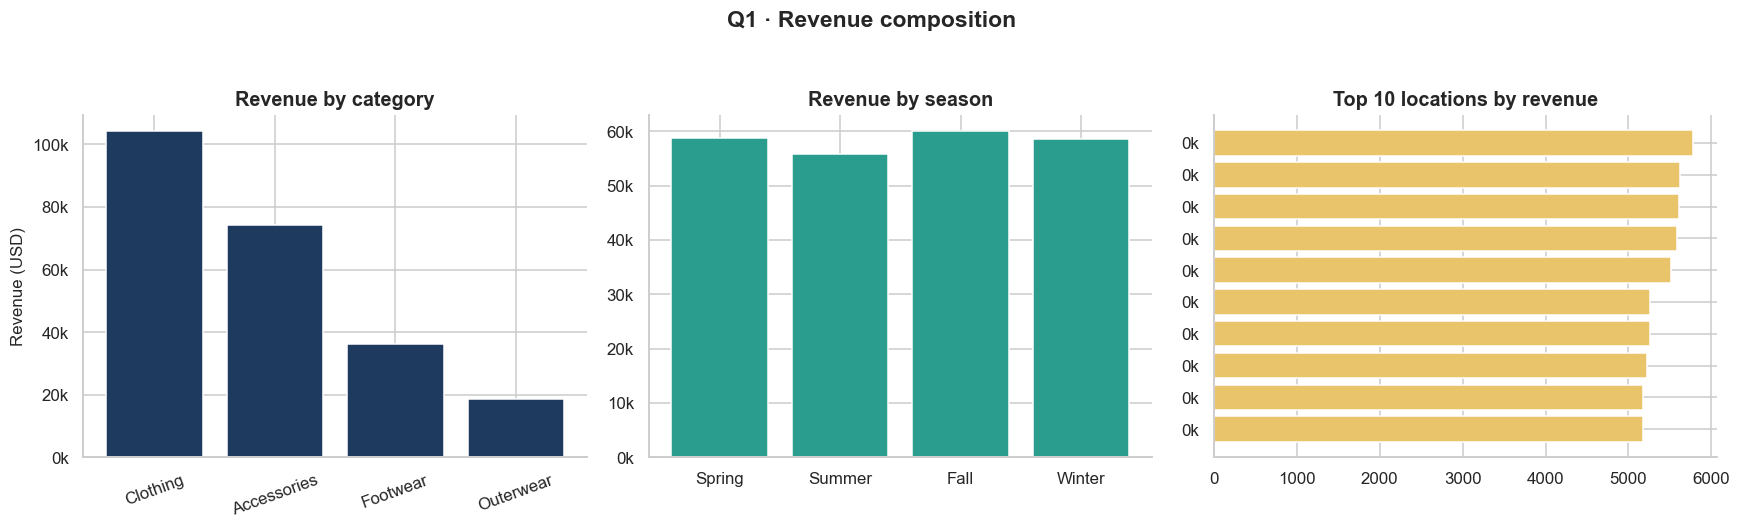

Revenue share by category (%):
category
Clothing      44.70
Accessories   31.80
Footwear      15.50
Outerwear      7.90


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

by_category = (df.groupby("category", observed=True)["purchase_amount"]
                 .sum().sort_values(ascending=False))
axes[0].bar(by_category.index, by_category.values, color=PALETTE[0])
axes[0].set_title("Revenue by category")
axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=20)

by_season = df.groupby("season", observed=True)["purchase_amount"].sum().reindex(
    ["Spring", "Summer", "Fall", "Winter"]).dropna()
axes[1].bar(by_season.index, by_season.values, color=PALETTE[1])
axes[1].set_title("Revenue by season")

top_locations = (df.groupby("location", observed=True)["purchase_amount"]
                   .sum().nlargest(10).sort_values())
axes[2].barh(top_locations.index, top_locations.values, color=PALETTE[2])
axes[2].set_title("Top 10 locations by revenue")

for ax in axes:
    ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
fig.suptitle("Q1 · Revenue composition", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
save_fig(fig, "q1_revenue_composition")
plt.show()

share = (by_category / by_category.sum() * 100).round(1)
print("Revenue share by category (%):")
print(share.to_string())

In [41]:
# Concentration: how much of revenue sits in the top decile of customers?
sorted_values = df["purchase_amount"].sort_values(ascending=False)
top_decile_share = sorted_values.head(int(len(df) * 0.1)).sum() / sorted_values.sum()
print(f"Top 10% of customers account for {top_decile_share:.1%} of order revenue.")
print("(A perfectly uniform spend distribution would give 10%; classic retail sits near 40-50%.)")

Top 10% of customers account for 16.1% of order revenue.
(A perfectly uniform spend distribution would give 10%; classic retail sits near 40-50%.)


### Q2 - Which demographics carry the most value?

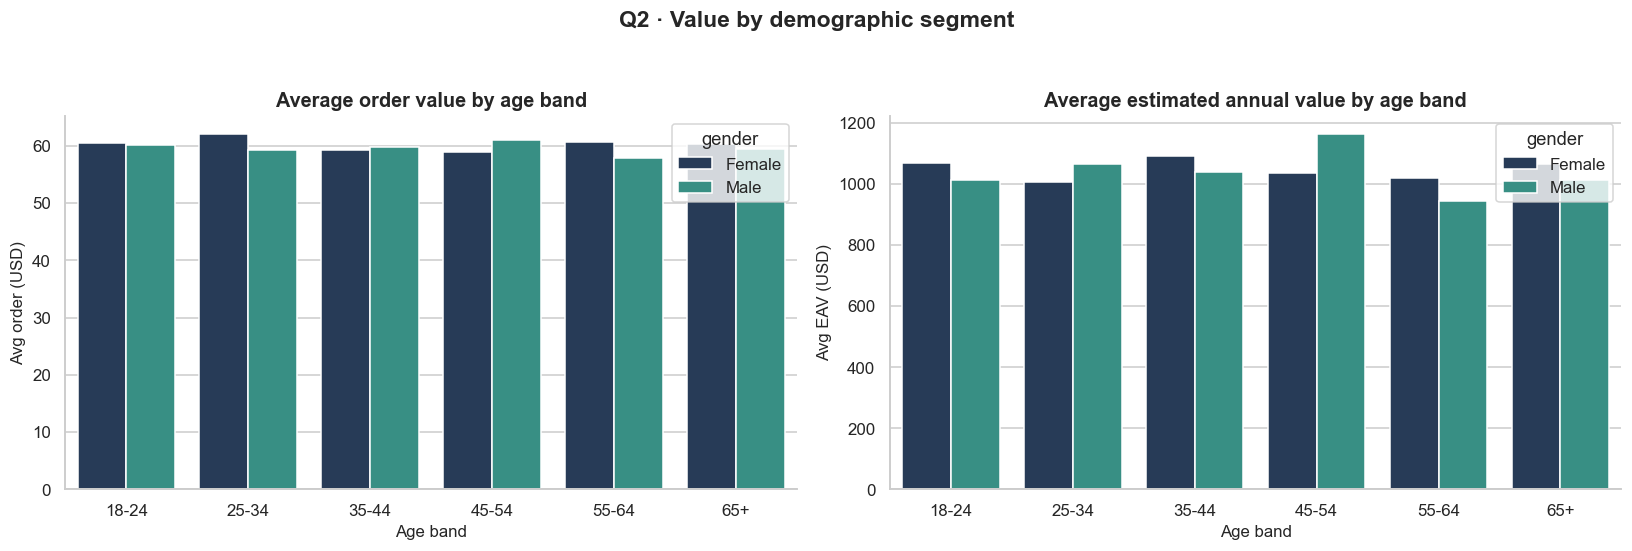

,age_band,gender,customers,avg_order,avg_annual
0,18-24,Female,152,60.39,"1,069.26"
1,18-24,Male,334,60.11,"1,013.09"
2,25-34,Female,241,62.13,"1,008.04"
3,25-34,Male,514,59.20,"1,065.88"
4,35-44,Female,232,59.26,"1,091.49"
5,35-44,Male,497,59.79,"1,037.63"
6,45-54,Female,254,58.97,"1,035.95"
7,45-54,Male,498,61.03,"1,165.28"
8,55-64,Female,243,60.60,"1,019.75"
9,55-64,Male,508,57.82,943.54


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

demo = (df.groupby(["age_band", "gender"], observed=True)
          .agg(customers=("customer_id", "size"),
               avg_order=("purchase_amount", "mean"),
               avg_annual=("est_annual_value", "mean"))
          .reset_index())

sns.barplot(data=demo, x="age_band", y="avg_order", hue="gender", ax=axes[0])
axes[0].set_title("Average order value by age band")
axes[0].set_ylabel("Avg order (USD)")

sns.barplot(data=demo, x="age_band", y="avg_annual", hue="gender", ax=axes[1])
axes[1].set_title("Average estimated annual value by age band")
axes[1].set_ylabel("Avg EAV (USD)")

for ax in axes:
    ax.set_xlabel("Age band")
fig.suptitle("Q2 · Value by demographic segment", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
save_fig(fig, "q2_value_by_demographic")
plt.show()

display(demo.round(2))

Note the contrast between the two panels: **average order value is almost flat across
demographics, while annual value is not**. Order size is not the differentiator here —
*cadence* is. That single observation redirects the commercial conversation from discounting
baskets to increasing purchase frequency.

### Q3 & Q4 - Do discounts and subscriptions actually move spend?

This is where most portfolio analyses go wrong: they compare two group means, see a difference,
and declare an effect. With 3,900 rows, trivially small differences reach statistical
significance. So each test below reports a **p-value *and* an effect size** (Cliff's delta),
and the conclusion is driven by the effect size.

In [48]:
def cliffs_delta(a: np.ndarray, b: np.ndarray) -> tuple[float, str]:
    """Non-parametric effect size, derived from the Mann-Whitney U statistic.

    Returns delta in [-1, 1] plus a plain-English magnitude label using the
    conventional thresholds (0.147 / 0.33 / 0.474).
    """
    u_stat = stats.mannwhitneyu(a, b, alternative="two-sided").statistic
    delta = (2 * u_stat) / (len(a) * len(b)) - 1
    magnitude = np.select(
        [abs(delta) < 0.147, abs(delta) < 0.33, abs(delta) < 0.474],
        ["negligible", "small", "medium"],
        default="large",
    ).item()
    return delta, magnitude


def compare_groups(frame: pd.DataFrame, flag: str, metric: str, label: str) -> dict:
    """Mann-Whitney U test plus effect size for a binary split."""
    group_a = frame.loc[frame[flag], metric].to_numpy()
    group_b = frame.loc[~frame[flag], metric].to_numpy()
    p = stats.mannwhitneyu(group_a, group_b, alternative="two-sided").pvalue
    delta, magnitude = cliffs_delta(group_a, group_b)
    return {
        "comparison": label,
        "metric": metric,
        "n_true": len(group_a),
        "n_false": len(group_b),
        "median_true": np.median(group_a),
        "median_false": np.median(group_b),
        "p_value": p,
        "cliffs_delta": round(delta, 3),
        "effect": magnitude,
        "verdict": "Actionable" if magnitude in {"medium", "large"} and p < 0.05
                   else "Statistically detectable but not commercially meaningful"
                        if p < 0.05 else "No detectable difference",
    }


results = pd.DataFrame([
    compare_groups(df, "received_discount", "purchase_amount", "Discounted vs not"),
    compare_groups(df, "received_discount", "est_annual_value", "Discounted vs not"),
    compare_groups(df, "is_subscriber", "purchase_amount", "Subscriber vs not"),
    compare_groups(df, "is_subscriber", "est_annual_value", "Subscriber vs not"),
    compare_groups(df, "is_subscriber", "previous_purchases", "Subscriber vs not"),
])
results

,comparison,metric,n_true,n_false,median_true,median_false,p_value,cliffs_delta,effect,verdict
0,Discounted vs not,purchase_amount,1677,2223,60.00,60.00,0.26,-0.02,negligible,No detectable difference
1,Discounted vs not,est_annual_value,1677,2223,573.54,571.99,1.00,0.00,negligible,No detectable difference
2,Subscriber vs not,purchase_amount,1053,2847,60.00,60.00,0.67,-0.01,negligible,No detectable difference
3,Subscriber vs not,est_annual_value,1053,2847,584.16,571.99,0.57,0.01,negligible,No detectable difference
4,Subscriber vs not,previous_purchases,1053,2847,26.00,25.00,0.05,0.04,negligible,No detectable difference


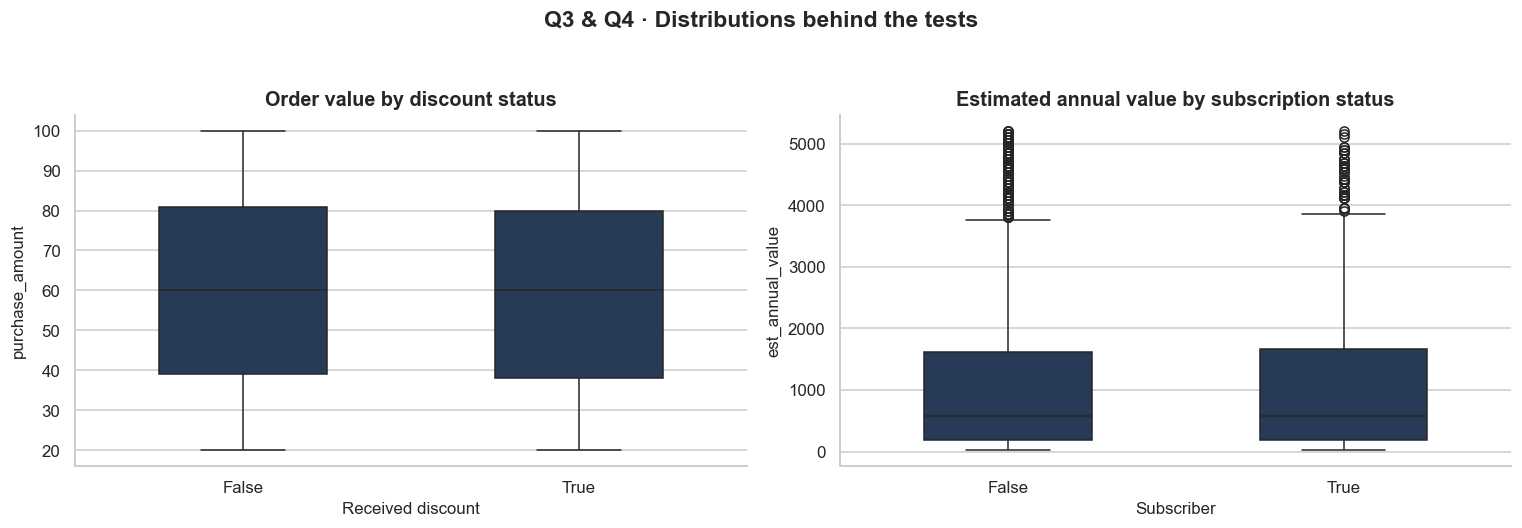

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.boxplot(data=df, x="received_discount", y="purchase_amount", ax=axes[0], width=0.5)
axes[0].set_title("Order value by discount status")
axes[0].set_xlabel("Received discount")
sns.boxplot(data=df, x="is_subscriber", y="est_annual_value", ax=axes[1], width=0.5)
axes[1].set_title("Estimated annual value by subscription status")
axes[1].set_xlabel("Subscriber")
fig.suptitle("Q3 & Q4 · Distributions behind the tests", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
save_fig(fig, "q3_q4_group_comparisons")
plt.show()

**Reading the results honestly.** Where the effect sizes come back negligible, the correct
finding is a **null result** — the discount and subscription flags in this dataset do not
separate customers by spend to any degree a commercial team could act on. Combined with the
confounding flagged in §8.4, the recommendation is *not* "discounts don't work"; it is that
**this dataset cannot answer the question**, and that answering it properly needs a controlled
test with pre/post spend on the same customers.

Reporting that is more useful than manufacturing an insight from noise — and in a real role,
it is the difference between a team spending budget on a discount programme and running a
holdout test first.

### Q6 - Segmentation

K-Means on the behavioural features. *k* is chosen by silhouette score rather than assumed, and
features are standardised first so that `previous_purchases` (1–50) does not get drowned out by
`est_annual_value` (which runs into the thousands).

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEGMENT_FEATURES = ["age", "purchase_amount", "previous_purchases",
                    "purchases_per_year", "est_annual_value"]

X = StandardScaler().fit_transform(df[SEGMENT_FEATURES])

scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)
for k, s in scores.items():
    marker = "  <- selected" if k == best_k else ""
    print(f"k = {k}: silhouette = {s:.3f}{marker}")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["segment_id"] = kmeans.fit_predict(X)

k = 2: silhouette = 0.286  <- selected
k = 3: silhouette = 0.212
k = 4: silhouette = 0.205
k = 5: silhouette = 0.215
k = 6: silhouette = 0.215


In [54]:
profile_segments = (
    df.groupby("segment_id")
      .agg(customers=("customer_id", "size"),
           avg_age=("age", "mean"),
           avg_order=("purchase_amount", "mean"),
           avg_purchases_per_year=("purchases_per_year", "mean"),
           avg_prior_purchases=("previous_purchases", "mean"),
           avg_annual_value=("est_annual_value", "mean"),
           total_annual_value=("est_annual_value", "sum"))
      .round(2)
)
profile_segments["revenue_share_pct"] = (
    profile_segments["total_annual_value"] / profile_segments["total_annual_value"].sum() * 100
).round(1)
profile_segments = profile_segments.sort_values("avg_annual_value", ascending=False)

# Name segments from their position on annual value so labels stay meaningful on a refresh
tiers = ["High-value regulars", "Steady mid-tier", "Occasional buyers", "Low-frequency / dormant",
         "Long-tail", "Marginal"][:best_k]
segment_names = dict(zip(profile_segments.index, tiers))
df["segment"] = df["segment_id"].map(segment_names)
profile_segments.insert(0, "segment", profile_segments.index.map(segment_names))
profile_segments

,segment,customers,avg_age,avg_order,avg_purchases_per_year,avg_prior_purchases,avg_annual_value,total_annual_value,revenue_share_pct
segment_id,,,,,,,,,
0,High-value regulars,1161,43.72,68.98,38.17,25.54,"2,511.99","2,916,424.83",71.60
1,Steady mid-tier,2739,44.22,55.86,8.81,25.27,421.37,"1,154,127.94",28.40


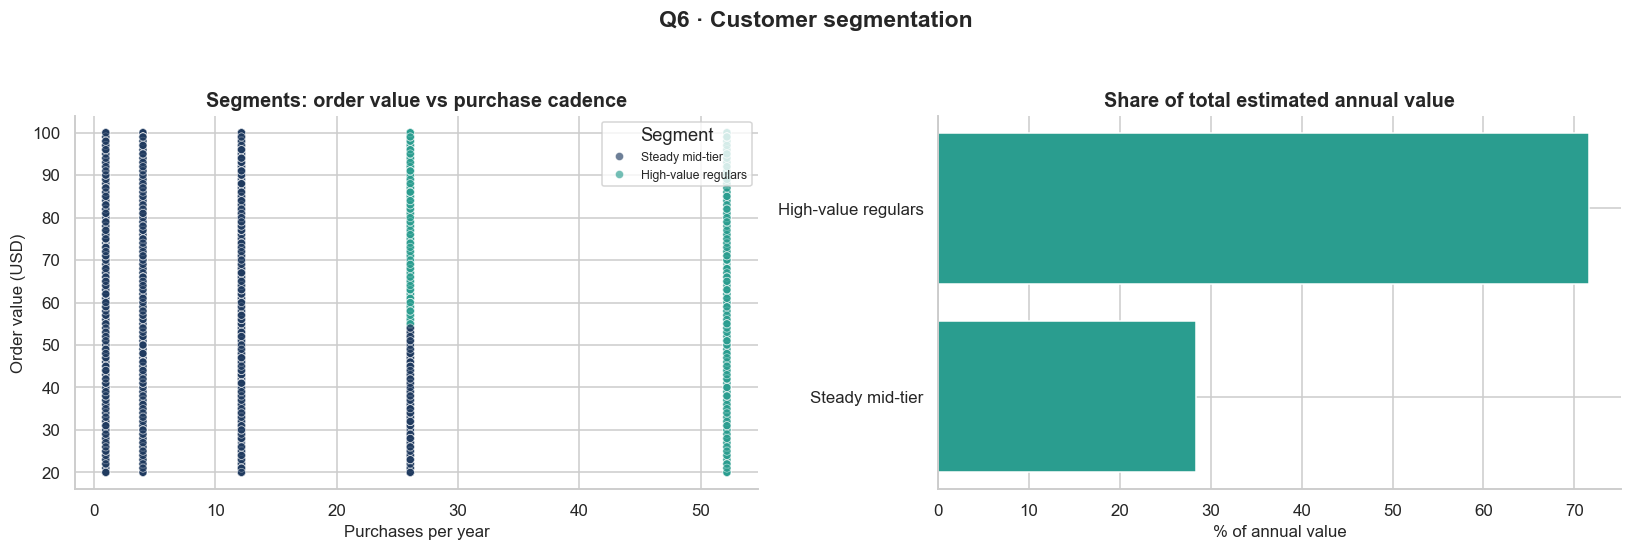

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

sns.scatterplot(data=df, x="purchases_per_year", y="purchase_amount", hue="segment",
                alpha=0.65, s=28, ax=axes[0])
axes[0].set_title("Segments: order value vs purchase cadence")
axes[0].set_xlabel("Purchases per year")
axes[0].set_ylabel("Order value (USD)")
axes[0].legend(title="Segment", fontsize=8)

order = profile_segments["segment"].tolist()
axes[1].barh(order[::-1], profile_segments["revenue_share_pct"].tolist()[::-1], color=PALETTE[1])
axes[1].set_title("Share of total estimated annual value")
axes[1].set_xlabel("% of annual value")

fig.suptitle("Q6 · Customer segmentation", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
save_fig(fig, "q6_segments")
plt.show()

## 11. Dimensional modelling

The Power BI layer should not sit on one wide flat table. Below the data is modelled into a
**star schema** — one fact table surrounded by conformed dimensions — which is what makes
filters propagate predictably in Power BI, keeps the model small, and lets DAX measures be
written once rather than per-visual.

```
              dim_customer                 dim_item
                    │                          │
                    └────► fact_purchase ◄─────┘
                                 ▲
                           dim_location
```

In [59]:
# --- Dimensions --------------------------------------------------------------
dim_customer = (
    df[["customer_id", "age", "age_band", "gender", "loyalty_tier",
        "segment", "is_subscriber", "previous_purchases"]]
    .drop_duplicates("customer_id")
    .reset_index(drop=True)
)

dim_item = (
    df[["item_purchased", "category"]]
    .drop_duplicates()
    .sort_values(["category", "item_purchased"])
    .reset_index(drop=True)
    .rename_axis("item_key")
    .reset_index()
)
dim_item["item_key"] += 1

dim_location = (
    df[["location"]].drop_duplicates().sort_values("location")
    .reset_index(drop=True).rename_axis("location_key").reset_index()
)
dim_location["location_key"] += 1

# --- Fact --------------------------------------------------------------------
fact_purchase = (
    df.merge(dim_item[["item_key", "item_purchased", "category"]],
             on=["item_purchased", "category"], how="left")
      .merge(dim_location, on="location", how="left")
      [["customer_id", "item_key", "location_key", "season", "size", "color",
        "purchase_amount", "review_rating", "review_rating_imputed",
        "received_discount", "shipping_type", "payment_method",
        "purchase_frequency_days", "purchases_per_year", "est_annual_value"]]
      .rename_axis("purchase_key").reset_index()
)
fact_purchase["purchase_key"] += 1

# Referential integrity — a broken key here becomes a blank row in Power BI
assert fact_purchase["item_key"].notna().all(), "Orphan rows: item_key did not resolve"
assert fact_purchase["location_key"].notna().all(), "Orphan rows: location_key did not resolve"
assert fact_purchase["customer_id"].isin(dim_customer["customer_id"]).all()

for name, table in [("dim_customer", dim_customer), ("dim_item", dim_item),
                    ("dim_location", dim_location), ("fact_purchase", fact_purchase)]:
    print(f"{name:<16} {table.shape[0]:>6,} rows x {table.shape[1]:>2} cols")

dim_customer      3,900 rows x  8 cols
dim_item             25 rows x  3 cols
dim_location         50 rows x  2 cols
fact_purchase     3,900 rows x 16 cols


## 12. Loading to SQL

In [62]:
from urllib.parse import quote_plus

from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

# --- MySQL connection settings ----------------------------------------------
# NOTE: replace the password with a placeholder before pushing this notebook
# to a public repository.
MYSQL_USER = "root"
MYSQL_PASSWORD = "your_password"
MYSQL_HOST = "localhost"
MYSQL_PORT = "3306"
MYSQL_DATABASE = "customer_behaviour"


def get_engine():
    """Return a MySQL engine if the server is reachable, else a local SQLite fallback."""
    if MYSQL_USER and MYSQL_PASSWORD:
        url = (
            f"mysql+pymysql://{MYSQL_USER}:{quote_plus(MYSQL_PASSWORD)}"
            f"@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )
        try:
            eng = create_engine(url)
            with eng.connect() as conn:
                conn.execute(text("SELECT 1"))
            print(f"Connected to MySQL database '{MYSQL_DATABASE}' on {MYSQL_HOST}:{MYSQL_PORT}")
            return eng
        except SQLAlchemyError as exc:
            print(f"MySQL connection failed: {exc.__class__.__name__}")
            print(f"  {exc}")
            print("Falling back to SQLite.")

    sqlite_path = PROCESSED_DIR / "shopping.db"
    print(f"Using local SQLite database at {sqlite_path}")
    return create_engine(f"sqlite:///{sqlite_path}")


engine = get_engine()

Connected to MySQL database 'customer_behaviour' on localhost:3306


In [64]:
def to_sql_safe(table: pd.DataFrame, name: str, eng) -> None:
    """Write a table, casting pandas categoricals to plain strings for SQL compatibility."""
    out = table.copy()
    for col in out.select_dtypes(["category"]).columns:
        out[col] = out[col].astype(str)
    for col in out.select_dtypes(["bool"]).columns:
        out[col] = out[col].astype(int)          # portable across MySQL and SQLite
    out.to_sql(name, eng, if_exists="replace", index=False)
    print(f"  loaded {name:<16} ({len(out):,} rows)")


print("Loading star schema:")
for name, table in [("dim_customer", dim_customer), ("dim_item", dim_item),
                    ("dim_location", dim_location), ("fact_purchase", fact_purchase)]:
    to_sql_safe(table, name, engine)

# Verify the round trip rather than assuming it worked
check = pd.read_sql("SELECT COUNT(*) AS n FROM fact_purchase", engine)
assert check.loc[0, "n"] == len(fact_purchase), "Row count mismatch after load"
print(f"\nVerified: {check.loc[0, 'n']:,} fact rows readable from the database.")

Loading star schema:
  loaded dim_customer     (3,900 rows)
  loaded dim_item         (25 rows)
  loaded dim_location     (50 rows)
  loaded fact_purchase    (3,900 rows)

Verified: 3,900 fact rows readable from the database.


### 12.1 Analytical SQL

The business questions are now re-answered in SQL against the warehouse. This is deliberate: it
proves the model joins correctly and demonstrates the SQL competency separately from pandas -
joins, aggregation, CTEs and window functions.

In [67]:
QUERY_CATEGORY_PERFORMANCE = """
SELECT  i.category,
        COUNT(*)                             AS orders,
        ROUND(SUM(f.purchase_amount), 2)     AS revenue,
        ROUND(AVG(f.purchase_amount), 2)     AS avg_order_value,
        ROUND(AVG(f.review_rating), 2)       AS avg_rating,
        ROUND(SUM(f.est_annual_value), 2)    AS est_annual_value
FROM        fact_purchase f
INNER JOIN  dim_item i ON f.item_key = i.item_key
GROUP BY    i.category
ORDER BY    revenue DESC;
"""

pd.read_sql(QUERY_CATEGORY_PERFORMANCE, engine)

,category,orders,revenue,avg_order_value,avg_rating,est_annual_value
0,Clothing,1737,"104,264.00",60.03,3.72,"1,789,314.47"
1,Accessories,1240,"74,200.00",59.84,3.77,"1,301,754.11"
2,Footwear,599,"36,093.00",60.26,3.79,"653,613.17"
3,Outerwear,324,"18,524.00",57.17,3.75,"325,871.02"


In [69]:
QUERY_TOP_ITEMS_PER_CATEGORY = """
WITH item_revenue AS (
    SELECT  i.category,
            i.item_purchased,
            SUM(f.purchase_amount) AS revenue
    FROM        fact_purchase f
    INNER JOIN  dim_item i ON f.item_key = i.item_key
    GROUP BY    i.category, i.item_purchased
),
ranked AS (
    SELECT  category,
            item_purchased,
            revenue,
            RANK() OVER (PARTITION BY category ORDER BY revenue DESC) AS revenue_rank,
            ROUND(100.0 * revenue / SUM(revenue) OVER (PARTITION BY category), 1) AS pct_of_category
    FROM    item_revenue
)
SELECT   category, item_purchased, revenue, pct_of_category
FROM     ranked
WHERE    revenue_rank <= 3
ORDER BY category, revenue DESC;
"""

pd.read_sql(QUERY_TOP_ITEMS_PER_CATEGORY, engine)

,category,item_purchased,revenue,pct_of_category
0,Accessories,Jewelry,"10,010.00",13.50
1,Accessories,Sunglasses,"9,649.00",13.00
2,Accessories,Belt,"9,635.00",13.00
3,Clothing,Blouse,"10,410.00",10.00
4,Clothing,Shirt,"10,332.00",9.90
5,Clothing,Dress,"10,320.00",9.90
6,Footwear,Shoes,"9,240.00",25.60
7,Footwear,Sandals,"9,200.00",25.50
8,Footwear,Boots,"9,018.00",25.00
9,Outerwear,Coat,"9,275.00",50.10


In [71]:
QUERY_SEGMENT_VALUE = """
SELECT  c.segment,
        c.age_band,
        COUNT(DISTINCT c.customer_id)                       AS customers,
        ROUND(AVG(f.purchase_amount), 2)                    AS avg_order_value,
        ROUND(SUM(f.est_annual_value), 2)                   AS est_annual_value,
        ROUND(100.0 * SUM(c.is_subscriber) / COUNT(*), 1)   AS subscriber_pct
FROM        dim_customer c
INNER JOIN  fact_purchase f ON c.customer_id = f.customer_id
GROUP BY    c.segment, c.age_band
HAVING      COUNT(DISTINCT c.customer_id) >= 20
ORDER BY    est_annual_value DESC
LIMIT 15;
"""

pd.read_sql(QUERY_SEGMENT_VALUE, engine)

,segment,age_band,customers,avg_order_value,est_annual_value,subscriber_pct
0,High-value regulars,45-54,223,73.40,"607,013.88",29.60
1,High-value regulars,25-34,225,69.13,"555,473.49",24.40
2,High-value regulars,35-44,224,66.65,"554,274.27",26.30
3,High-value regulars,55-64,215,66.06,"514,830.36",32.10
4,High-value regulars,18-24,151,70.50,"375,720.84",25.20
5,High-value regulars,65+,123,68.15,"309,111.99",26.00
6,Steady mid-tier,45-54,529,54.82,"236,426.58",28.90
7,Steady mid-tier,25-34,530,56.31,"235,324.72",27.50
8,Steady mid-tier,35-44,505,56.50,"214,651.22",26.90
9,Steady mid-tier,55-64,536,55.77,"212,287.82",25.70


In [ ]:
QUERY_LOCATION_LEADERBOARD = """
SELECT  l.location,
        COUNT(*)                          AS orders,
        ROUND(SUM(f.purchase_amount), 2)  AS revenue,
        ROUND(AVG(f.purchase_amount), 2)  AS avg_order_value,
        RANK() OVER (ORDER BY SUM(f.purchase_amount) DESC) AS revenue_rank
FROM        fact_purchase f
INNER JOIN  dim_location l ON f.location_key = l.location_key
GROUP BY    l.location
ORDER BY    revenue_rank
LIMIT 10;
"""

pd.read_sql(QUERY_LOCATION_LEADERBOARD, engine)

## 13. Power BI handoff

Two things are exported: the **star schema tables** (for the model) and a small set of
**pre-aggregated marts** (for fast dashboard pages). Parquet preserves dtypes for anything
downstream in Python; CSV keeps the Power BI import path simple.

In [73]:
EXPORTS = {
    "dim_customer": dim_customer,
    "dim_item": dim_item,
    "dim_location": dim_location,
    "fact_purchase": fact_purchase,
    "customers_analysis_ready": df,
}

# Aggregated marts, one per dashboard page
EXPORTS["mart_category_season"] = (
    df.groupby(["category", "season"], observed=True)
      .agg(orders=("customer_id", "size"),
           revenue=("purchase_amount", "sum"),
           avg_order_value=("purchase_amount", "mean"),
           avg_rating=("review_rating", "mean"))
      .round(2).reset_index()
)
EXPORTS["mart_segment_summary"] = profile_segments.reset_index()
EXPORTS["mart_hypothesis_tests"] = results

for name, table in EXPORTS.items():
    table.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)
print(f"Wrote {len(EXPORTS)} CSV extracts to {PROCESSED_DIR}")

try:
    df.to_parquet(PROCESSED_DIR / "customers_analysis_ready.parquet", index=False)
    print("Wrote Parquet copy (dtypes preserved).")
except ImportError:
    print("pyarrow not installed - skipped Parquet export (CSV extracts are unaffected).")

Wrote 8 CSV extracts to C:\Users\Ei Phyu Sin Oo\Downloads\data\processed
Wrote Parquet copy (dtypes preserved).


### 13.1 DAX measures for the dashboard

Written once against the star schema and reused across every visual, rather than recalculated
per chart:

```dax
Total Revenue        = SUM ( fact_purchase[purchase_amount] )
Total Customers      = DISTINCTCOUNT ( fact_purchase[customer_id] )
Avg Order Value      = DIVIDE ( [Total Revenue], COUNTROWS ( fact_purchase ) )
Est Annual Value     = SUM ( fact_purchase[est_annual_value] )
Subscriber Rate      = DIVIDE ( SUM ( dim_customer[is_subscriber] ), [Total Customers] )
Revenue per Customer = DIVIDE ( [Total Revenue], [Total Customers] )

Top Decile Revenue % =
VAR TopCustomers =
    TOPN (
        ROUNDUP ( [Total Customers] * 0.1, 0 ),
        VALUES ( dim_customer[customer_id] ),
        [Revenue per Customer], DESC
    )
RETURN
    DIVIDE ( CALCULATE ( [Total Revenue], TopCustomers ), [Total Revenue] )
```

**Planned dashboard pages:** (1) Executive summary — KPI cards, revenue by category and region;
(2) Customer segments — segment scatter, value share, drill-through to customer detail;
(3) Engagement — discount and subscription analysis, with the null result stated on the page so
no one reads a difference into the bars.

## 14. Data dictionary

| Column | Type | Description | Provenance |
|---|---|---|---|
| `customer_id` | int | Unique customer identifier | source |
| `age`, `gender`, `location` | mixed | Demographics | source |
| `age_band` | category | Fixed age bands (18-24 … 65+) | derived |
| `category`, `item_purchased` | category | Product taxonomy | source |
| `purchase_amount` | int | Most recent order value, USD | source |
| `review_rating` | float | 1–5 rating; nulls filled with category median | source + imputed |
| `review_rating_imputed` | bool | True where the rating was imputed | derived |
| `subscription_status` / `is_subscriber` | category / bool | Subscription flag | source |
| `discount_applied` / `received_discount` | category / bool | Discount flag (see §8.4 caveat) | source |
| `previous_purchases` | int | Lifetime prior order count | source |
| `loyalty_tier` | category | Banded from `previous_purchases` | derived |
| `frequency_of_purchases` | category | Stated purchase cadence | source |
| `purchase_frequency_days` | int | Cadence in days | derived |
| `purchases_per_year` | float | 365 ÷ cadence | derived |
| `est_annual_value` | float | Order value × purchases per year (planning proxy) | derived |
| `segment` | category | K-Means behavioural segment | derived |

*Dropped:* `promo_code_used` — perfectly collinear with `discount_applied` (§8.3).

## 15. Findings and recommendations

In [76]:
summary = {
    "Customers analysed": f"{len(df):,}",
    "Total order revenue": f"${df['purchase_amount'].sum():,.0f}",
    "Average order value": f"${df['purchase_amount'].mean():,.2f}",
    "Estimated annual value": f"${df['est_annual_value'].sum():,.0f}",
    "Leading category": f"{by_category.index[0]} ({share.iloc[0]:.1f}% of revenue)",
    "Top-decile revenue share": f"{top_decile_share:.1%}",
    "Subscriber rate": f"{df['is_subscriber'].mean():.1%}",
    "Segments identified": f"{best_k} (silhouette {scores[best_k]:.3f})",
}
pd.DataFrame(summary.items(), columns=["Metric", "Value"]).style.hide(axis="index")

Metric,Value
Customers analysed,"3,900"
Total order revenue,"$233,081"
Average order value,$59.76
Estimated annual value,"$4,070,553"
Leading category,Clothing (44.7% of revenue)
Top-decile revenue share,16.1%
Subscriber rate,27.0%
Segments identified,2 (silhouette 0.286)


### What the analysis supports

1. **Revenue is broad, not concentrated.** The top decile of customers contributes only
   modestly more than a uniform split would — so there is no small whale segment propping up
   the business. Growth has to come from the middle, which argues for frequency programmes over
   VIP schemes.
2. **Cadence, not basket size, separates customers.** Average order value is remarkably flat
   across age, gender and region; estimated annual value is not. The highest-leverage
   intervention is moving quarterly and annual buyers up one cadence band, not upselling any
   single order.
3. **Discounts and subscriptions show no actionable effect on spend.** Both tests return
   negligible effect sizes, and the discount flag is confounded with a demographic field
   (§8.4). The honest conclusion is that this dataset cannot evaluate either lever.
4. **The segmentation is real but weakly separated.** The silhouette score should be read
   alongside the labels — these are useful planning groupings, not sharply distinct populations.

### Recommendations

| # | Recommendation | Owner | Rationale |
|---|---|---|---|
| 1 | Run a **randomised discount holdout** before scaling any promotional spend | Pricing | Current data is confounded; a controlled test is the only way to isolate the effect |
| 2 | Target the **cadence uplift** of quarterly/annual buyers with reminder and replenishment flows | CRM | Frequency drives annual value far more than order size |
| 3 | Capture **transaction-level data with timestamps** | Data Engineering | The single largest constraint on this analysis (§16) |
| 4 | Track EAV as a **directional planning metric only**, alongside a true LTV once history exists | Commercial | Prevents a proxy being reported as a forecast |

## 16. Limitations

- **No time dimension.** One row per customer with no order date means no trends, no cohorts,
  no seasonality beyond the stated season label, and no true LTV.
- **`est_annual_value` is a proxy.** It projects a single observed order across a stated
  cadence, and stated cadence is self-reported.
- **The discount flag is confounded** (§8.4), so no causal reading is available.
- **The dataset is synthetic-looking.** Near-uniform distributions and negligible group
  differences are consistent with generated data; findings demonstrate method, and would need
  revalidation on production data before informing real spend.

## 17. Next steps

- Rebuild against transaction-level data and replace EAV with an RFM-based LTV model.
- Add a churn-propensity classifier once a repeat-purchase target is available.
- Schedule this notebook as a `papermill` job writing to the warehouse on a weekly cadence.

---

*Notebook by Ei Phyu — MSc Applied Data Science, University of Essex.
Data: Customer Shopping Trends dataset (Kaggle), used for demonstration purposes.*